In [35]:
import operator
from typing import Annotated, TypedDict
from IPython.display import Image, display
import asyncio

from langgraph.graph import StateGraph, START, END

### Task 1

In [4]:
class CustomerSupportState(TypedDict):
    ticket_id: str
    messages: Annotated[str, operator.add]
    extract_issues: list[str]
    priority: str
    human_approve_status: bool
    human_approval_request: list[str]
    solutions: Annotated[list[str], operator.add]

### Task 2

In [7]:
class ConfidenceState(TypedDict):
    confidence: float
    answer: str


def get_confidence_score(state: ConfidenceState) -> dict:
    # actutal logic here for confidence
    return {"confidence", state.get("confidence", 0)}


def re_create(state: ConfidenceState) -> dict:
    return {"confidence": 0.7}


def genrate_answer(state: ConfidenceState) -> dict:
    return {"answer": f"Your answer based on you score {state['confidence']}"}


def route_after_confidence(state: ConfidenceState) -> str:
    return "genrate_answer" if state["confidence"] >= 0.5 else "re_create"

In [13]:
builder = StateGraph(ConfidenceState)

builder.add_node("get_confidence_score", get_confidence_score)
builder.add_node("re_create", re_create)
builder.add_node("genrate_answer", genrate_answer)

builder.add_edge(START, "get_confidence_score")
builder.add_conditional_edges(
    "get_confidence_score", route_after_confidence, ["genrate_answer", "re_create"]
)
builder.add_edge("re_create", "genrate_answer")
builder.add_edge("genrate_answer", END)

graph = builder.compile()

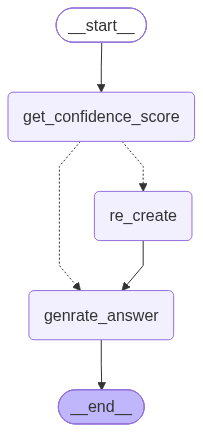

In [14]:
graph

### Task 3

In [15]:
class ToolState(TypedDict):
    tool_provider: str
    task: str
    result: str


def call_tool(state: ToolState) -> dict:
    # actual tool call here
    result = f"Tool : f{state['tool_provider']} for task : {state['task']}"
    return {"result": result}

### Task 6

In [27]:
def visualize_mermaid(graph):
    mermaid = graph.get_graph().draw_mermaid()
    print(mermaid)


def visualize_graph(graph):
    png = graph.get_graph().draw_mermaid_png()
    display(Image(png))

In [28]:
visualize_mermaid(graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	get_confidence_score(get_confidence_score)
	re_create(re_create)
	genrate_answer(genrate_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> get_confidence_score;
	get_confidence_score -.-> genrate_answer;
	get_confidence_score -.-> re_create;
	re_create --> genrate_answer;
	genrate_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



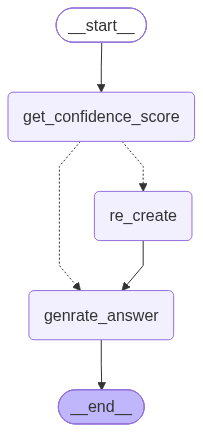

In [24]:
visualize_graph(graph)

### Task 7

In [30]:
class FailState(TypedDict):
    result: str


def failing_node(state: FailState):
    raise ValueError("Something went wrong in failing node!")


def safe_node(state: FailState):
    try:
        return failing_node(state)
    except Exception as e:
        return {"result": f"Error handled: {e}"}


builder = StateGraph(FailState)

builder.add_node("process", safe_node)

builder.add_edge(START, "process")
builder.add_edge("process", END)

graph = builder.compile()

result = graph.invoke({"result": ""})

print(result)

{'result': 'Error handled: Something went wrong in failing node!'}


### Task 9

In [36]:
class TicketState(TypedDict, total=False):
    ticket_id: str
    customer: str
    analysis: str
    draft: str
    sent: bool


async def load_ticket(state: TicketState) -> dict:
    print("[node] load_ticket")
    await asyncio.sleep(1)

    return {"customer": "Acme Corp"}


async def analyze_ticker(state: TicketState) -> dict:
    print("[node] analyze_ticket")
    await asyncio.sleep(1)

    return {"analysis": "Duplicate billing is likely. Verify invoice/payment IDs."}


async def draft_response(state: TicketState) -> dict:
    print("[node] draft_response")
    await asyncio.sleep(1)

    return {
        "draft": (
            "Hi Acme Corp, we identified a possible duplicate charge. "
            "We are reviewing the payment records now."
        )
    }


async def send_response(state: TicketState) -> dict:
    print("[node] send_response")
    await asyncio.sleep(1)

    return {"sent": True}


def build_stream_graph():
    graph = StateGraph(TicketState)

    graph.add_node("load_ticket", load_ticket)
    graph.add_node("analyze_ticker", analyze_ticker)
    graph.add_node("draft_response", draft_response)
    graph.add_node("send_response", send_response)

    graph.set_entry_point("load_ticket")
    graph.add_edge("load_ticket", "analyze_ticker")
    graph.add_edge("analyze_ticker", "draft_response")
    graph.add_edge("draft_response", "send_response")
    graph.add_edge("send_response", END)

    return graph.compile()

In [39]:
async def log_state_history(graph, initial_state):
    async for update in graph.astream(
        initial_state,
        stream_mode="updates",
    ):
        print("STATE UPDATE:")
        print(update)
        print("-" * 50)

In [40]:
graph = build_stream_graph()
initial_state = {"ticket_id": "test-1002"}
await log_state_history(graph=graph, initial_state=initial_state)

[node] load_ticket
STATE UPDATE:
{'load_ticket': {'customer': 'Acme Corp'}}
--------------------------------------------------
[node] analyze_ticket
STATE UPDATE:
{'analyze_ticker': {'analysis': 'Duplicate billing is likely. Verify invoice/payment IDs.'}}
--------------------------------------------------
[node] draft_response
STATE UPDATE:
{'draft_response': {'draft': 'Hi Acme Corp, we identified a possible duplicate charge. We are reviewing the payment records now.'}}
--------------------------------------------------
[node] send_response
STATE UPDATE:
{'send_response': {'sent': True}}
--------------------------------------------------


### Task 10

In [44]:
class SupportState(TypedDict, total=False):
    customer_message: str

    technical_category: str
    technical_priority: str

    sentiment: str
    sentiment_score: float

    final_priority: str
    assigned_team: str
    final_summary: str


def technical_analysis(state: SupportState):
    message = state["customer_message"].lower()

    if "crash" in message or "error" in message:
        category = "technical_error"
        priority = "high"

    elif "slow" in message:
        category = "performance"
        priority = "medium"

    else:
        category = "general_technical"
        priority = "low"

    return {
        "technical_category": category,
        "technical_priority": priority,
    }


def sentiment_analysis(state: SupportState):
    message = state["customer_message"].lower()

    if any(word in message for word in ["angry", "terrible", "frustrated", "unacceptable"]):
        sentiment = "negative"
        score = 0.9

    elif any(word in message for word in ["thanks", "great", "good"]):
        sentiment = "positive"
        score = 0.8

    else:
        sentiment = "neutral"
        score = 0.5

    return {
        "sentiment": sentiment,
        "sentiment_score": score,
    }


def final_triage(state: SupportState):
    technical_priority = state["technical_priority"]
    sentiment = state["sentiment"]

    if technical_priority == "high" and sentiment == "negative":
        final_priority = "critical"
        team = "technical_support"

    elif technical_priority == "high":
        final_priority = "high"
        team = "technical_support"

    elif sentiment == "negative":
        final_priority = "medium"
        team = "customer_success"

    else:
        final_priority = technical_priority
        team = "general_support"

    summary = (
        f"Category: {state['technical_category']}. "
        f"Sentiment: {sentiment}. "
        f"Priority: {final_priority}. "
        f"Assigned team: {team}."
    )

    return {
        "final_priority": final_priority,
        "assigned_team": team,
        "final_summary": summary,
    }


builder = StateGraph(SupportState)

builder.add_node("technical_analysis", technical_analysis)
builder.add_node("sentiment_analysis", sentiment_analysis)
builder.add_node("final_triage", final_triage)

builder.add_edge(START, "technical_analysis")
builder.add_edge(START, "sentiment_analysis")

builder.add_edge("technical_analysis", "final_triage")
builder.add_edge("sentiment_analysis", "final_triage")

builder.add_edge("final_triage", END)

graph = builder.compile()

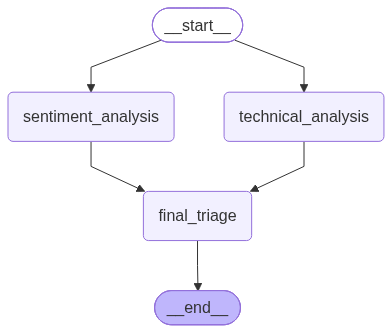

In [45]:
graph

In [46]:
result = graph.invoke(
    {"customer_message": "This application keeps crashing and this is absolutely unacceptable!"}
)

print(result)

{'customer_message': 'This application keeps crashing and this is absolutely unacceptable!', 'technical_category': 'technical_error', 'technical_priority': 'high', 'sentiment': 'negative', 'sentiment_score': 0.9, 'final_priority': 'critical', 'assigned_team': 'technical_support', 'final_summary': 'Category: technical_error. Sentiment: negative. Priority: critical. Assigned team: technical_support.'}
